# Autoencoder Architecture Comparison
Train: 2013–2023 | Test: 2024–2026 | K=5 latent factors

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns

RESULTS = Path(".")  # run from results/
FACTORS = RESULTS / "factors"
ERRORS  = RESULTS / "errors"

ARCHITECTURES = [
    "VanillaAE", "DenoisingAE", "SparseAE", "ContractiveAE",
    "MaskedAE", "VAE", "BetaVAE", "RecurrentAE",
]
BASELINE = "VanillaAE"

# Load recon errors
train_errors = {
    name: pd.read_csv(ERRORS / f"{name}_train_recon_error.csv", index_col=0, parse_dates=True)
    for name in ARCHITECTURES
}
test_errors = {
    name: pd.read_csv(ERRORS / f"{name}_test_recon_error.csv", index_col=0, parse_dates=True)
    for name in ARCHITECTURES
}

# Per-commodity MSE tables
def mse_table(errors_dict):
    rows = {}
    for name, err in errors_dict.items():
        per_com = (err ** 2).mean()
        per_com["ALL"] = float((err.to_numpy() ** 2).mean())
        rows[name] = per_com
    return pd.DataFrame(rows).T

train_mse_tbl = mse_table(train_errors)
test_mse_tbl  = mse_table(test_errors)

# Summary table
base_test    = test_mse_tbl.loc[BASELINE, "ALL"]
base_per_com = test_mse_tbl.loc[BASELINE].drop("ALL")

rows = []
for name in ARCHITECTURES:
    per_com = test_mse_tbl.loc[name].drop("ALL")
    ratios  = per_com / base_per_com
    rows.append({
        "architecture":          name,
        "train_recon_mse":       train_mse_tbl.loc[name, "ALL"],
        "test_recon_mse":        test_mse_tbl.loc[name, "ALL"],
        "test_mse_ratio":        test_mse_tbl.loc[name, "ALL"] / base_test,
        "median_commodity_ratio": float(ratios.median()),
        "n_commodities_better":  int((ratios < 1).sum()),
    })

summary   = pd.DataFrame(rows).set_index("architecture").sort_values("test_mse_ratio")
arch_order = summary.index.tolist()

## Summary Table

In [2]:
summary.round(4)

,train_recon_mse,test_recon_mse,test_mse_ratio,median_commodity_ratio,n_commodities_better
architecture,,,,,
RecurrentAE,0.5111,0.6176,0.9197,0.9359,22
ContractiveAE,0.5953,0.6649,0.9901,0.9916,18
SparseAE,0.5986,0.6702,0.9980,0.9987,17
DenoisingAE,0.5984,0.6707,0.9987,0.9954,17
VanillaAE,0.5991,0.6715,1.0000,1.0000,0
MaskedAE,0.6791,0.7590,1.1303,1.0852,5
VAE,0.6786,0.7750,1.1542,1.1162,6
BetaVAE,0.8305,0.9922,1.4776,1.4089,2


## Per-Commodity Reconstruction MSE

In [3]:
print("--- Train ---")
display(train_mse_tbl.loc[arch_order].round(4))

--- Train ---


,Coffee,SoybeanOil,Corn,Cotton,HRWWheat,LeanHogs,LiveCattle,Soybeans,Sugar,Brent,...,Silver,Copper,Aluminium,Nickel,Zinc,Platinum,HRCSteel,SGXIronOre,Lithium,ALL
RecurrentAE,0.8086,0.5482,0.3419,0.7335,0.4682,0.8795,0.7966,0.3989,0.7885,0.1298,...,0.1638,0.3298,0.4617,0.5114,0.3454,0.3167,0.7359,0.6961,0.5029,0.5111
ContractiveAE,0.8545,0.6280,0.4247,0.7820,0.5111,0.8774,0.7419,0.4789,0.7847,0.2442,...,0.2415,0.4321,0.5614,0.6738,0.4781,0.3940,0.9325,0.8956,0.7763,0.5953
SparseAE,0.8541,0.6286,0.4370,0.7812,0.5140,0.8857,0.7762,0.4778,0.7738,0.2498,...,0.2502,0.4392,0.5650,0.6695,0.4608,0.4042,0.9403,0.9032,0.7722,0.5986
DenoisingAE,0.8461,0.6241,0.4301,0.7832,0.5092,0.9063,0.7830,0.4782,0.7811,0.2462,...,0.2576,0.4266,0.5527,0.6582,0.4380,0.4045,0.9457,0.9079,0.7711,0.5984
VanillaAE,0.8525,0.6299,0.4391,0.7789,0.5113,0.8969,0.7828,0.4831,0.7746,0.2498,...,0.2533,0.4318,0.5559,0.6623,0.4437,0.4061,0.9418,0.9058,0.7722,0.5991
MaskedAE,0.9101,0.6738,0.5527,0.8717,0.6288,0.9885,0.9928,0.5417,0.8952,0.2663,...,0.2930,0.4486,0.6262,0.6925,0.5418,0.4599,1.0029,1.0096,0.9979,0.6791
VAE,0.8724,0.6071,0.4568,0.8316,0.5184,0.9089,0.9772,0.5426,0.8435,0.3172,...,0.4297,0.5376,0.6866,0.7170,0.6242,0.5077,0.9771,0.9805,0.9504,0.6786
BetaVAE,0.9188,0.7546,0.8734,0.8782,0.8924,0.9857,0.9818,0.8251,0.9092,0.5459,...,0.7834,0.6533,0.7693,0.8131,0.7496,0.7565,0.9961,0.9978,0.9975,0.8305


In [4]:
print("--- Test ---")
display(test_mse_tbl.loc[arch_order].round(4))

--- Test ---


,Coffee,SoybeanOil,Corn,Cotton,HRWWheat,LeanHogs,LiveCattle,Soybeans,Sugar,Brent,...,Silver,Copper,Aluminium,Nickel,Zinc,Platinum,HRCSteel,SGXIronOre,Lithium,ALL
RecurrentAE,1.1195,0.6984,0.2674,0.6733,0.4508,0.5424,0.6953,0.2811,0.7773,0.1704,...,0.9078,1.1260,0.4427,0.3118,0.3664,0.8499,0.6443,0.5097,1.2582,0.6176
ContractiveAE,1.1171,0.7402,0.2809,0.6066,0.4569,0.5651,0.5124,0.3125,0.7806,0.2761,...,1.1867,1.3620,0.5028,0.3189,0.4770,1.0078,0.6707,0.4123,1.3986,0.6649
SparseAE,1.1203,0.7395,0.2917,0.6013,0.4568,0.5643,0.5360,0.3123,0.7768,0.2841,...,1.2308,1.3755,0.5033,0.3269,0.4636,1.0336,0.6744,0.4171,1.3658,0.6702
DenoisingAE,1.1119,0.7352,0.2834,0.6032,0.4548,0.5525,0.5364,0.3097,0.7789,0.2825,...,1.2501,1.3663,0.4932,0.3222,0.4430,1.0378,0.6797,0.4116,1.3835,0.6707
VanillaAE,1.1214,0.7401,0.2939,0.5984,0.4547,0.5597,0.5393,0.3160,0.7791,0.2844,...,1.2436,1.3709,0.4932,0.3269,0.4484,1.0377,0.6759,0.4191,1.3681,0.6715
MaskedAE,1.1533,0.8042,0.3579,0.6539,0.6282,0.5483,0.6409,0.3606,0.8379,0.2976,...,1.2214,1.4658,0.5761,0.3206,0.5124,1.1890,0.7334,0.4187,1.9328,0.7590
VAE,1.0962,0.7211,0.2914,0.6267,0.4815,0.5138,0.6325,0.3617,0.7872,0.3517,...,1.6542,1.5301,0.6496,0.3286,0.5766,1.2687,0.7077,0.4056,1.8461,0.7750
BetaVAE,1.1393,0.9157,0.5678,0.6488,0.7915,0.5327,0.6368,0.5976,0.8256,0.6264,...,2.6579,1.8706,0.7339,0.3405,0.6988,1.9961,0.7208,0.4069,1.9275,0.9922


## 1. Architecture Ranking — Test Reconstruction MSE

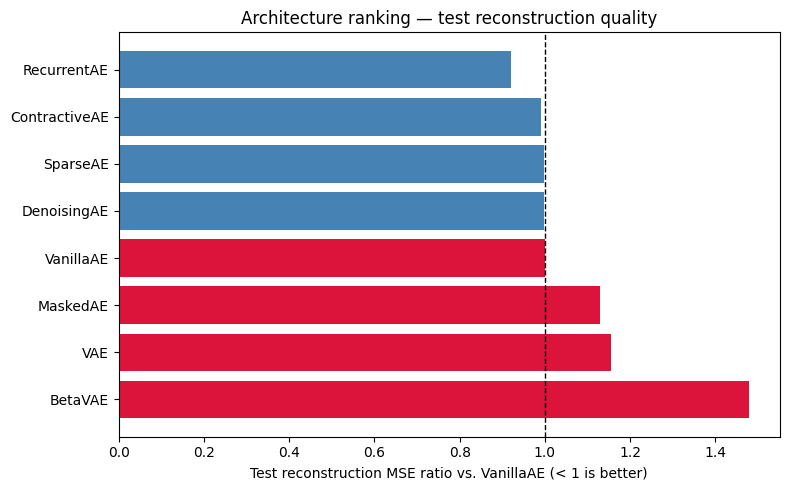

In [5]:
ordered = summary.sort_values("test_mse_ratio")
colors = ["steelblue" if r < 1 else "crimson" for r in ordered["test_mse_ratio"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(ordered.index[::-1], ordered["test_mse_ratio"][::-1], color=colors[::-1])
ax.axvline(1.0, color="k", lw=1, ls="--")
ax.set_xlabel("Test reconstruction MSE ratio vs. VanillaAE (< 1 is better)")
ax.set_title("Architecture ranking — test reconstruction quality")
fig.tight_layout()
plt.show()

## 2. Train vs Test MSE — Generalisation Gap

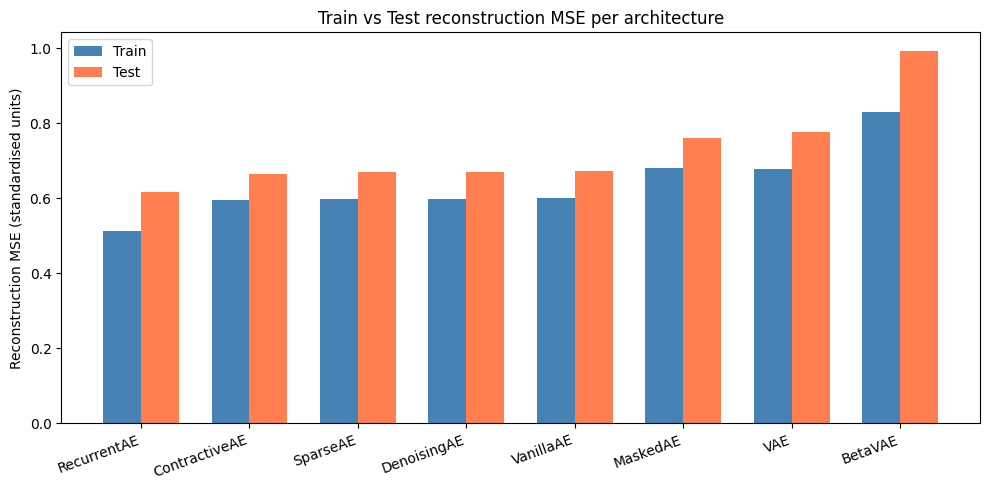

In [6]:
ordered = summary.loc[arch_order]
x = np.arange(len(ordered))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, ordered["train_recon_mse"], w, label="Train", color="steelblue")
ax.bar(x + w/2, ordered["test_recon_mse"],  w, label="Test",  color="coral")
ax.set_xticks(x)
ax.set_xticklabels(ordered.index, rotation=20, ha="right")
ax.set_ylabel("Reconstruction MSE (standardised units)")
ax.set_title("Train vs Test reconstruction MSE per architecture")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Per-Commodity MSE Heatmap

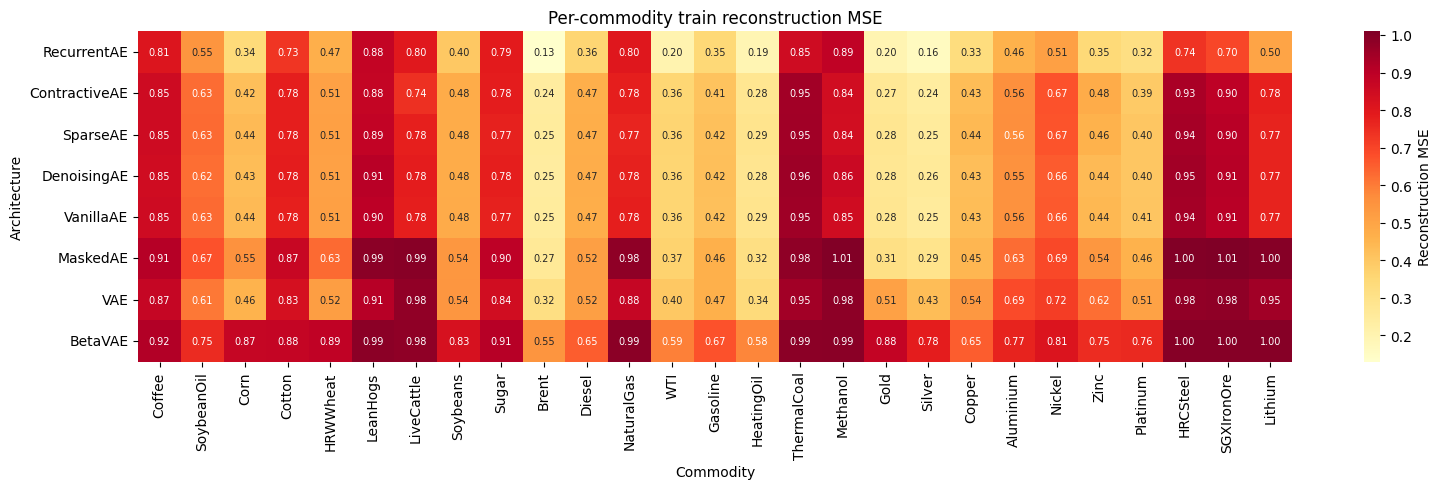

In [7]:
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    train_mse_tbl.drop(columns="ALL").loc[arch_order],
    cmap="YlOrRd", annot=True, fmt=".2f",
    annot_kws={"size": 7}, cbar_kws={"label": "Reconstruction MSE"}, ax=ax,
)
ax.set_title("Per-commodity train reconstruction MSE")
ax.set_xlabel("Commodity")
ax.set_ylabel("Architecture")
fig.tight_layout()
plt.show()

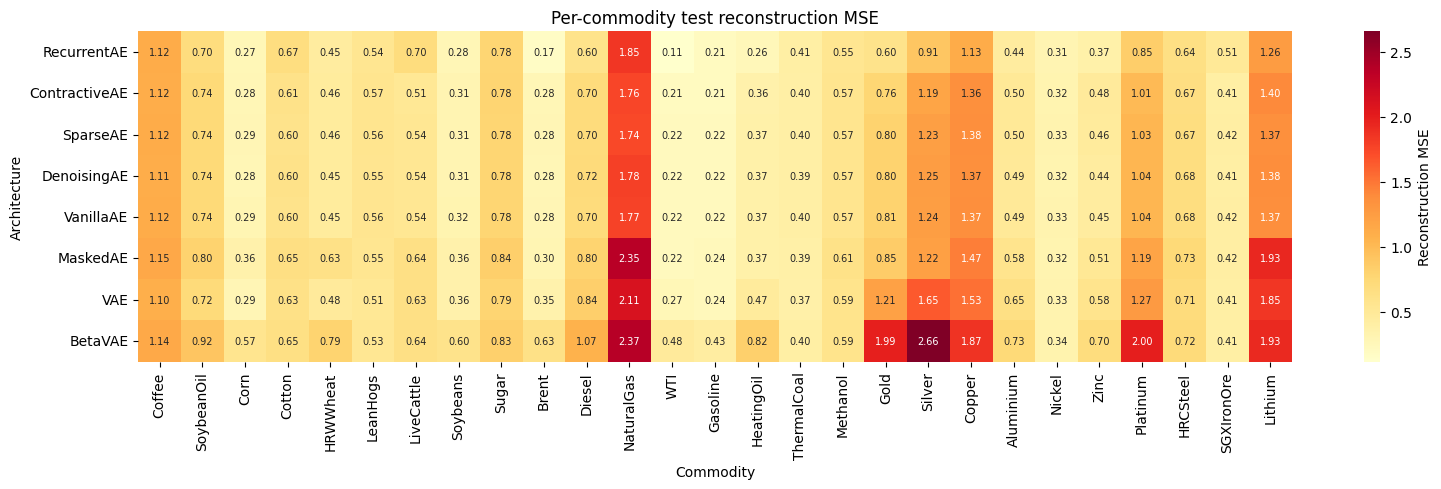

In [8]:
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    test_mse_tbl.drop(columns="ALL").loc[arch_order],
    cmap="YlOrRd", annot=True, fmt=".2f",
    annot_kws={"size": 7}, cbar_kws={"label": "Reconstruction MSE"}, ax=ax,
)
ax.set_title("Per-commodity test reconstruction MSE")
ax.set_xlabel("Commodity")
ax.set_ylabel("Architecture")
fig.tight_layout()
plt.show()

## 4. Factor Variances per Architecture

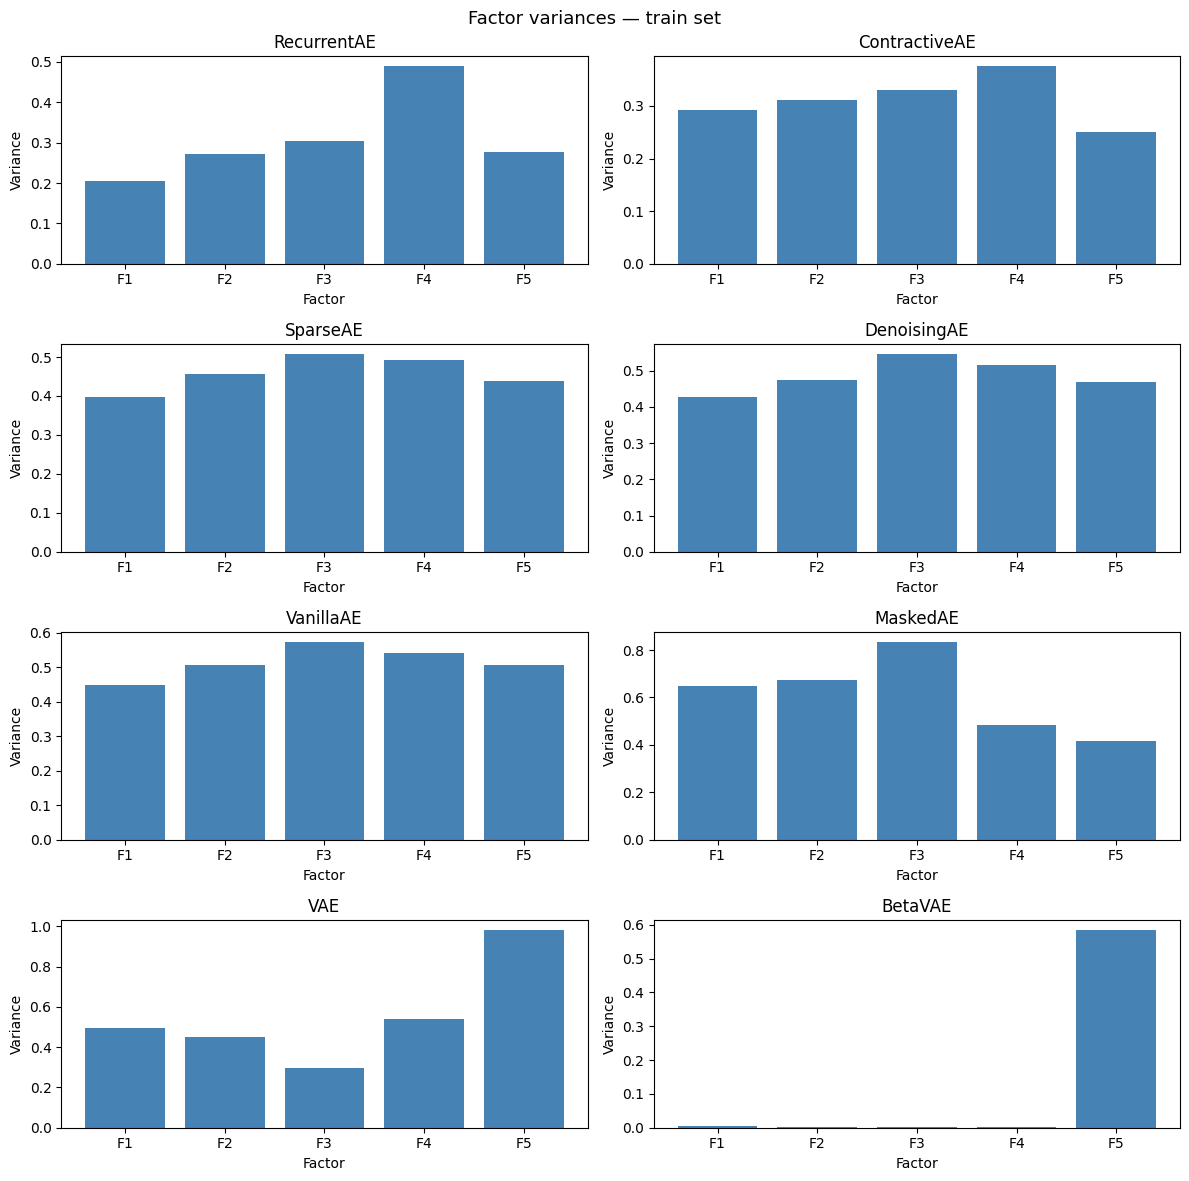

In [9]:
n = len(arch_order)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
axes = axes.flatten()
for ax, name in zip(axes, arch_order):
    var = pd.read_csv(FACTORS / f"{name}_train_factors.csv", index_col=0, parse_dates=True).var()
    ax.bar(var.index, var.values, color="steelblue")
    ax.set_title(name)
    ax.set_xlabel("Factor")
    ax.set_ylabel("Variance")
for ax in axes[len(arch_order):]:
    ax.set_visible(False)
fig.suptitle("Factor variances — train set", fontsize=13)
fig.tight_layout()
plt.show()

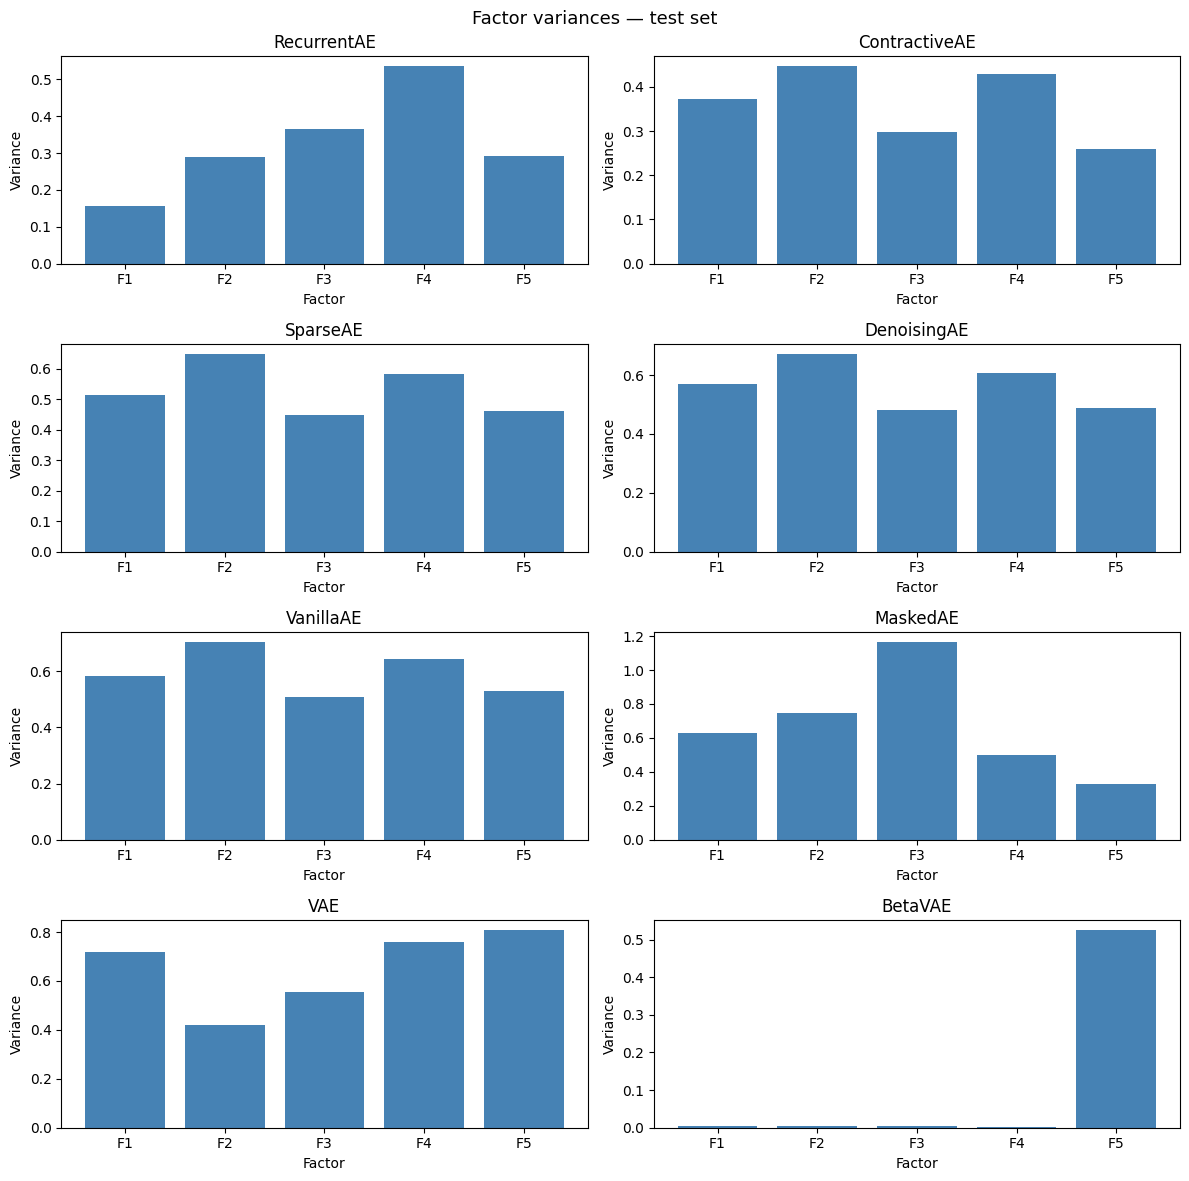

In [10]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
axes = axes.flatten()
for ax, name in zip(axes, arch_order):
    var = pd.read_csv(FACTORS / f"{name}_test_factors.csv", index_col=0, parse_dates=True).var()
    ax.bar(var.index, var.values, color="steelblue")
    ax.set_title(name)
    ax.set_xlabel("Factor")
    ax.set_ylabel("Variance")
for ax in axes[len(arch_order):]:
    ax.set_visible(False)
fig.suptitle("Factor variances — test set", fontsize=13)
fig.tight_layout()
plt.show()

## 5. Latent Factor Time Series

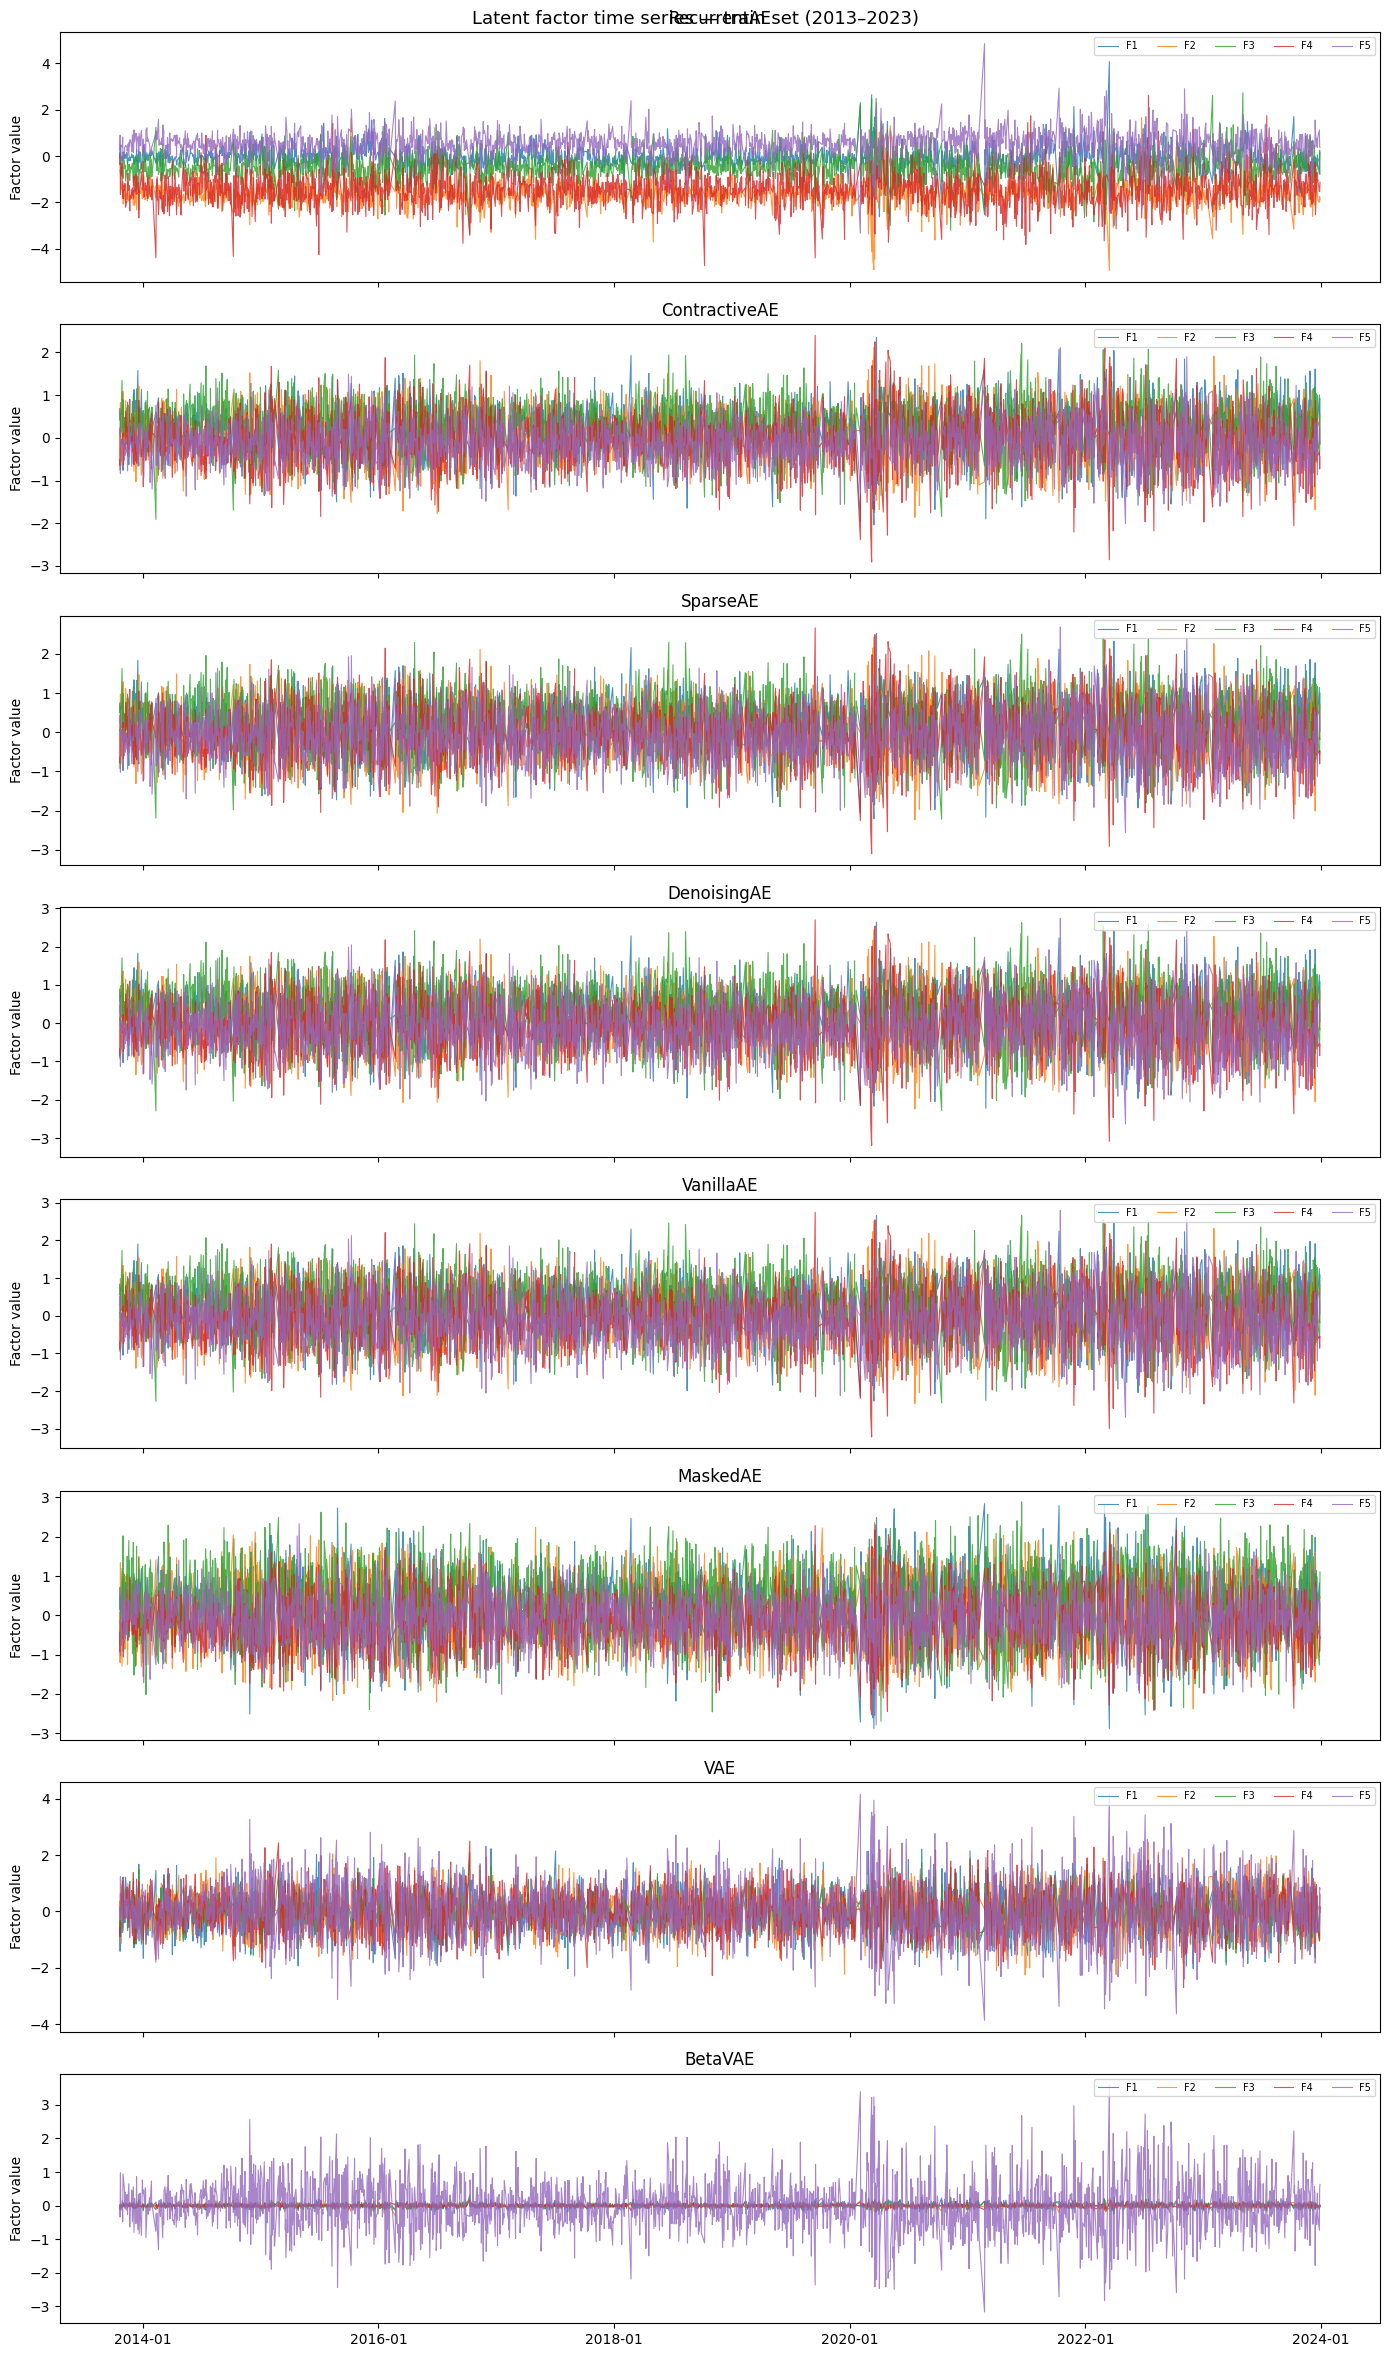

In [11]:
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)
for ax, name in zip(axes, arch_order):
    factors = pd.read_csv(FACTORS / f"{name}_train_factors.csv", index_col=0, parse_dates=True)
    for col in factors.columns:
        ax.plot(factors.index, factors[col], lw=0.8, alpha=0.8, label=col)
    ax.set_title(name)
    ax.set_ylabel("Factor value")
    ax.legend(loc="upper right", fontsize=7, ncol=5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.suptitle("Latent factor time series — train set (2013–2023)", fontsize=13)
fig.tight_layout()
plt.show()

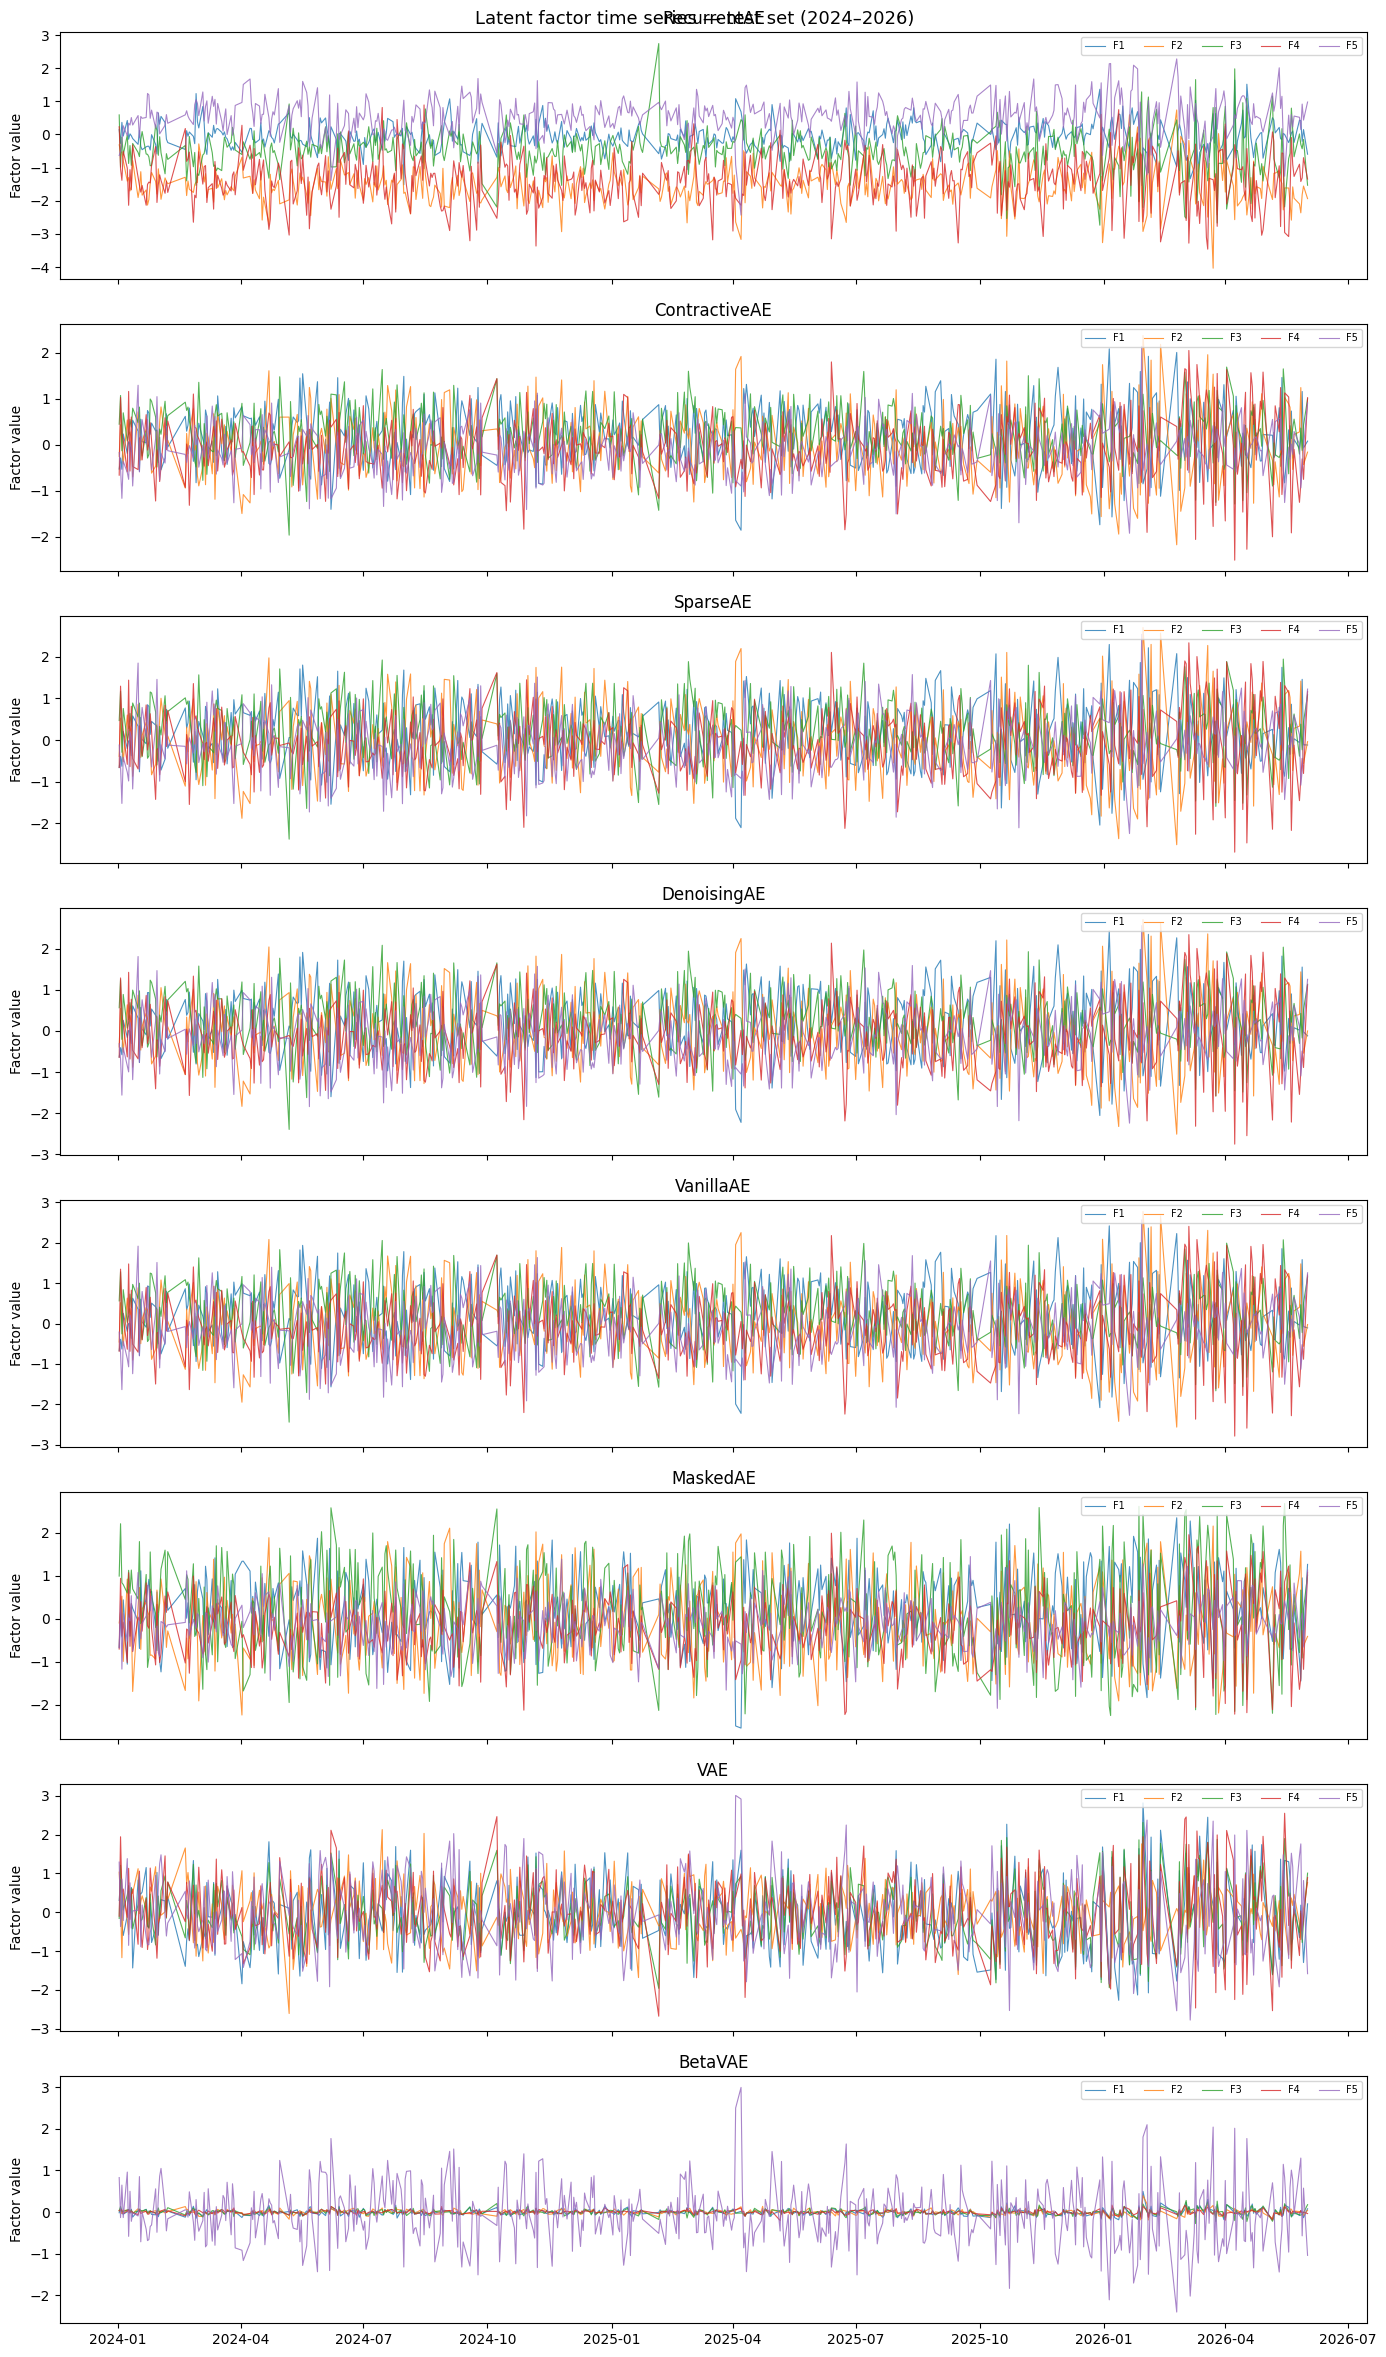

In [12]:
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)
for ax, name in zip(axes, arch_order):
    factors = pd.read_csv(FACTORS / f"{name}_test_factors.csv", index_col=0, parse_dates=True)
    for col in factors.columns:
        ax.plot(factors.index, factors[col], lw=0.8, alpha=0.8, label=col)
    ax.set_title(name)
    ax.set_ylabel("Factor value")
    ax.legend(loc="upper right", fontsize=7, ncol=5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.suptitle("Latent factor time series — test set (2024–2026)", fontsize=13)
fig.tight_layout()
plt.show()

## 6. R² Explained per Architecture

R² = 1 − MSE (valid because the input is z-scored, so the baseline variance = 1 per commodity).  
RMSE = √MSE.  
Shown for overall panel, per sector, and per commodity — train then test.

In [13]:
_SECTOR_MAP = {
    "Brent":"Energy","WTI":"Energy","NaturalGas":"Energy","Gasoline":"Energy",
    "Diesel":"Energy","HeatingOil":"Energy","ThermalCoal":"Energy","Methanol":"Energy",
    "Gold":"Metals","Silver":"Metals","Copper":"Metals","Aluminium":"Metals",
    "Nickel":"Metals","Zinc":"Metals","Platinum":"Metals","HRCSteel":"Metals",
    "SGXIronOre":"Metals","Lithium":"Metals",
    "Coffee":"Agriculture","Corn":"Agriculture","Cotton":"Agriculture",
    "LeanHogs":"Agriculture","LiveCattle":"Agriculture","Sugar":"Agriculture",
    "Soybeans":"Agriculture","SoybeanOil":"Agriculture","HRWWheat":"Agriculture",
}
_SECTOR_ORDER = ["Energy", "Metals", "Agriculture"]

def _metrics_df(mse_tbl):
    """Convert per-commodity MSE table → long DataFrame with MSE, RMSE, R²."""
    rows = []
    for arch in arch_order:
        for com in mse_tbl.drop(columns="ALL").columns:
            mse = mse_tbl.loc[arch, com]
            rows.append({
                "architecture": arch,
                "commodity":    com,
                "sector":       _SECTOR_MAP.get(com, "?"),
                "MSE":          mse,
                "RMSE":         np.sqrt(mse),
                "R2":           1.0 - mse,
            })
    return pd.DataFrame(rows)

train_metrics = _metrics_df(train_mse_tbl)
test_metrics  = _metrics_df(test_mse_tbl)

for label, df in [("Train (2013–2023)", train_metrics), ("Test (2024–2026)", test_metrics)]:
    print(f"\n{'═'*60}")
    print(f"  {label}")
    print(f"{'═'*60}")

    # Overall
    overall = df.groupby("architecture")[["MSE","RMSE","R2"]].mean().loc[arch_order]
    print("\n— Overall —")
    display(overall.round(4))

    # Per sector
    sector_tbl = (
        df.groupby(["architecture","sector"])[["MSE","RMSE","R2"]]
        .mean()
        .unstack("sector")
        .loc[arch_order]
        .reindex(columns=pd.MultiIndex.from_product([["MSE","RMSE","R2"], _SECTOR_ORDER]))
    )
    print("\n— Per sector —")
    display(sector_tbl.round(4))


════════════════════════════════════════════════════════════
  Train (2013–2023)
════════════════════════════════════════════════════════════

— Overall —


,MSE,RMSE,R2
architecture,,,
RecurrentAE,0.5111,0.6921,0.4889
ContractiveAE,0.5953,0.7562,0.4047
SparseAE,0.5986,0.7588,0.4014
DenoisingAE,0.5984,0.7582,0.4016
VanillaAE,0.5991,0.7589,0.4009
MaskedAE,0.6791,0.8073,0.3209
VAE,0.6786,0.8122,0.3214
BetaVAE,0.8305,0.9078,0.1695



— Per sector —


MSE                        RMSE                          R2  \
               Energy  Metals Agriculture  Energy  Metals Agriculture  Energy   
architecture                                                                    
RecurrentAE    0.4721  0.4259      0.6404  0.6503  0.6368      0.7906  0.5279   
ContractiveAE  0.5419  0.5654      0.6759  0.7155  0.7349      0.8160  0.4581   
SparseAE       0.5439  0.5683      0.6809  0.7177  0.7374      0.8191  0.4561   
DenoisingAE    0.5471  0.5640      0.6824  0.7190  0.7343      0.8196  0.4529   
VanillaAE      0.5467  0.5652      0.6832  0.7193  0.7353      0.8205  0.4533   
MaskedAE       0.6124  0.6381      0.7839  0.7587  0.7810      0.8797  0.3876   
VAE            0.6051  0.6922      0.7287  0.7595  0.8235      0.8464  0.3949   
BetaVAE        0.7511  0.8396      0.8910  0.8601  0.9141      0.9432  0.2489   

                                   
               Metals Agriculture  
architecture                       
RecurrentAE    0.5741      0.3596  
ContractiveAE  0.4346      0.3241  
SparseAE       0.4317      0.3191  
DenoisingAE    0.4360      0.3176  
VanillaAE      0.4348      0.3168  
MaskedAE       0.3619      0.2161  
VAE            0.3078      0.2713  
BetaVAE        0.1604      0.1090


════════════════════════════════════════════════════════════
  Test (2024–2026)
════════════════════════════════════════════════════════════

— Overall —


,MSE,RMSE,R2
architecture,,,
RecurrentAE,0.6176,0.7514,0.3824
ContractiveAE,0.6649,0.7831,0.3351
SparseAE,0.6702,0.7868,0.3298
DenoisingAE,0.6707,0.7862,0.3293
VanillaAE,0.6715,0.7872,0.3285
MaskedAE,0.7590,0.8312,0.2410
VAE,0.7750,0.8399,0.2250
BetaVAE,0.9922,0.9510,0.0078



— Per sector —


MSE                        RMSE                          R2  \
               Energy  Metals Agriculture  Energy  Metals Agriculture  Energy   
architecture                                                                    
RecurrentAE    0.5196  0.7013      0.6117  0.6535  0.8175      0.7650  0.4804   
ContractiveAE  0.5597  0.8102      0.5969  0.6985  0.8743      0.7569  0.4403   
SparseAE       0.5628  0.8193      0.5999  0.7023  0.8792      0.7593  0.4372   
DenoisingAE    0.5691  0.8189      0.5962  0.7047  0.8779      0.7567  0.4309   
VanillaAE      0.5671  0.8191      0.6003  0.7041  0.8786      0.7596  0.4329   
MaskedAE       0.6607  0.9221      0.6650  0.7440  0.9263      0.8030  0.3393   
VAE            0.6548  1.0175      0.6125  0.7539  0.9724      0.7691  0.3452   
BetaVAE        0.8486  1.3345      0.7395  0.8777  1.0973      0.8536  0.1514   

                                   
               Metals Agriculture  
architecture                       
RecurrentAE    0.2987      0.3883  
ContractiveAE  0.1898      0.4031  
SparseAE       0.1807      0.4001  
DenoisingAE    0.1811      0.4038  
VanillaAE      0.1809      0.3997  
MaskedAE       0.0779      0.3350  
VAE           -0.0175      0.3875  
BetaVAE       -0.3345      0.2605

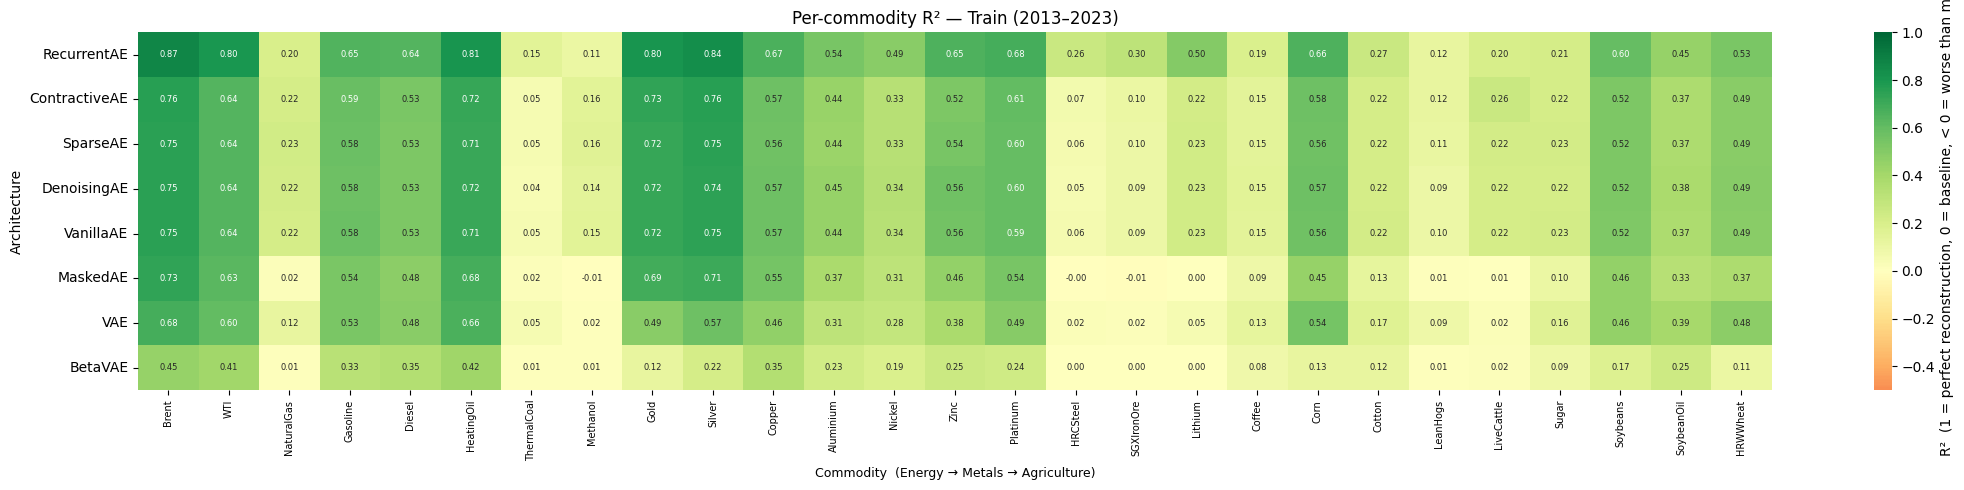

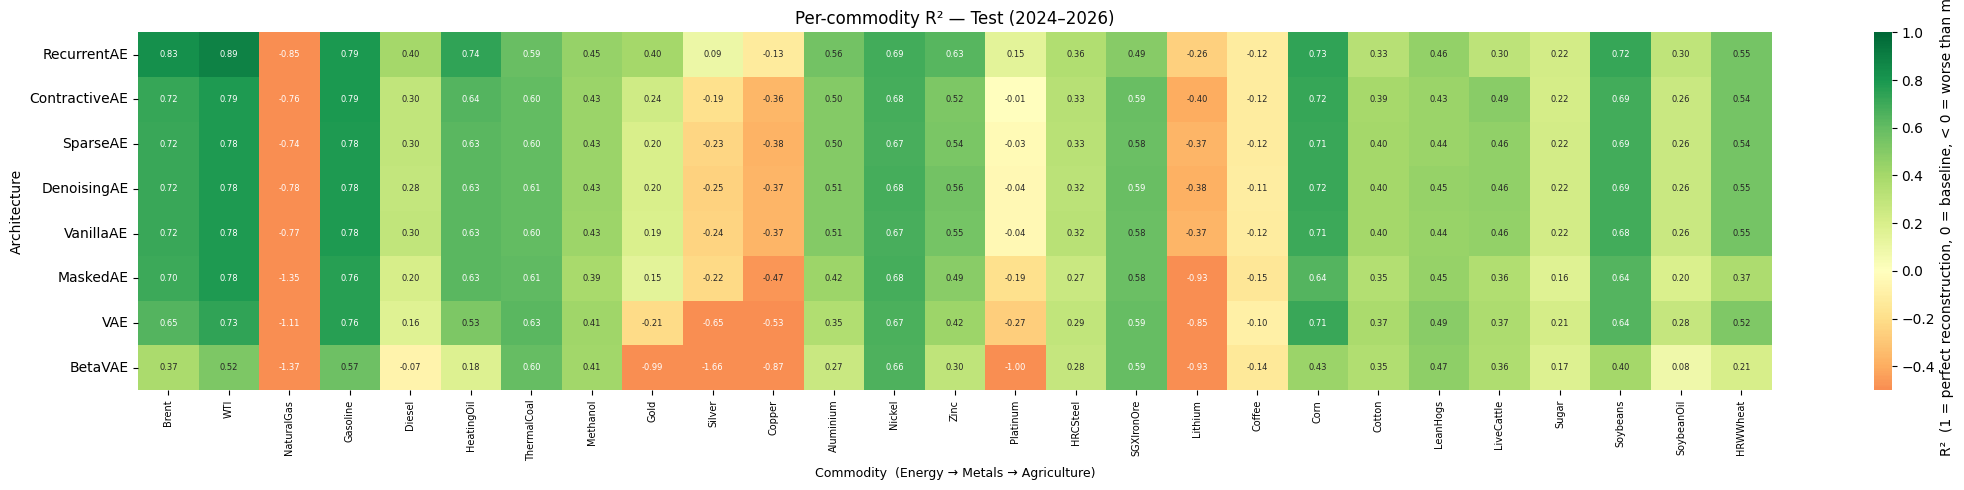

In [14]:
_COMMODITIES_ORDERED = sorted(
    _SECTOR_MAP,
    key=lambda c: (_SECTOR_ORDER.index(_SECTOR_MAP[c]), list(_SECTOR_MAP).index(c)),
)

for label, metrics in [("Train (2013–2023)", train_metrics), ("Test (2024–2026)", test_metrics)]:
    r2_wide = (
        metrics.pivot(index="architecture", columns="commodity", values="R2")
        .loc[arch_order, _COMMODITIES_ORDERED]
    )
    fig, ax = plt.subplots(figsize=(22, 5))
    sns.heatmap(
        r2_wide,
        cmap="RdYlGn", center=0, vmin=-0.5, vmax=1.0,
        annot=True, fmt=".2f", annot_kws={"size": 6},
        cbar_kws={"label": "R²  (1 = perfect reconstruction, 0 = baseline, < 0 = worse than mean)"},
        ax=ax,
    )
    ax.set_title(f"Per-commodity R² — {label}", fontsize=12)
    ax.set_xlabel("Commodity  (Energy → Metals → Agriculture)", fontsize=9)
    ax.set_ylabel("Architecture")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    fig.tight_layout()
    plt.show()

## 7. Factor Correlation Heatmaps

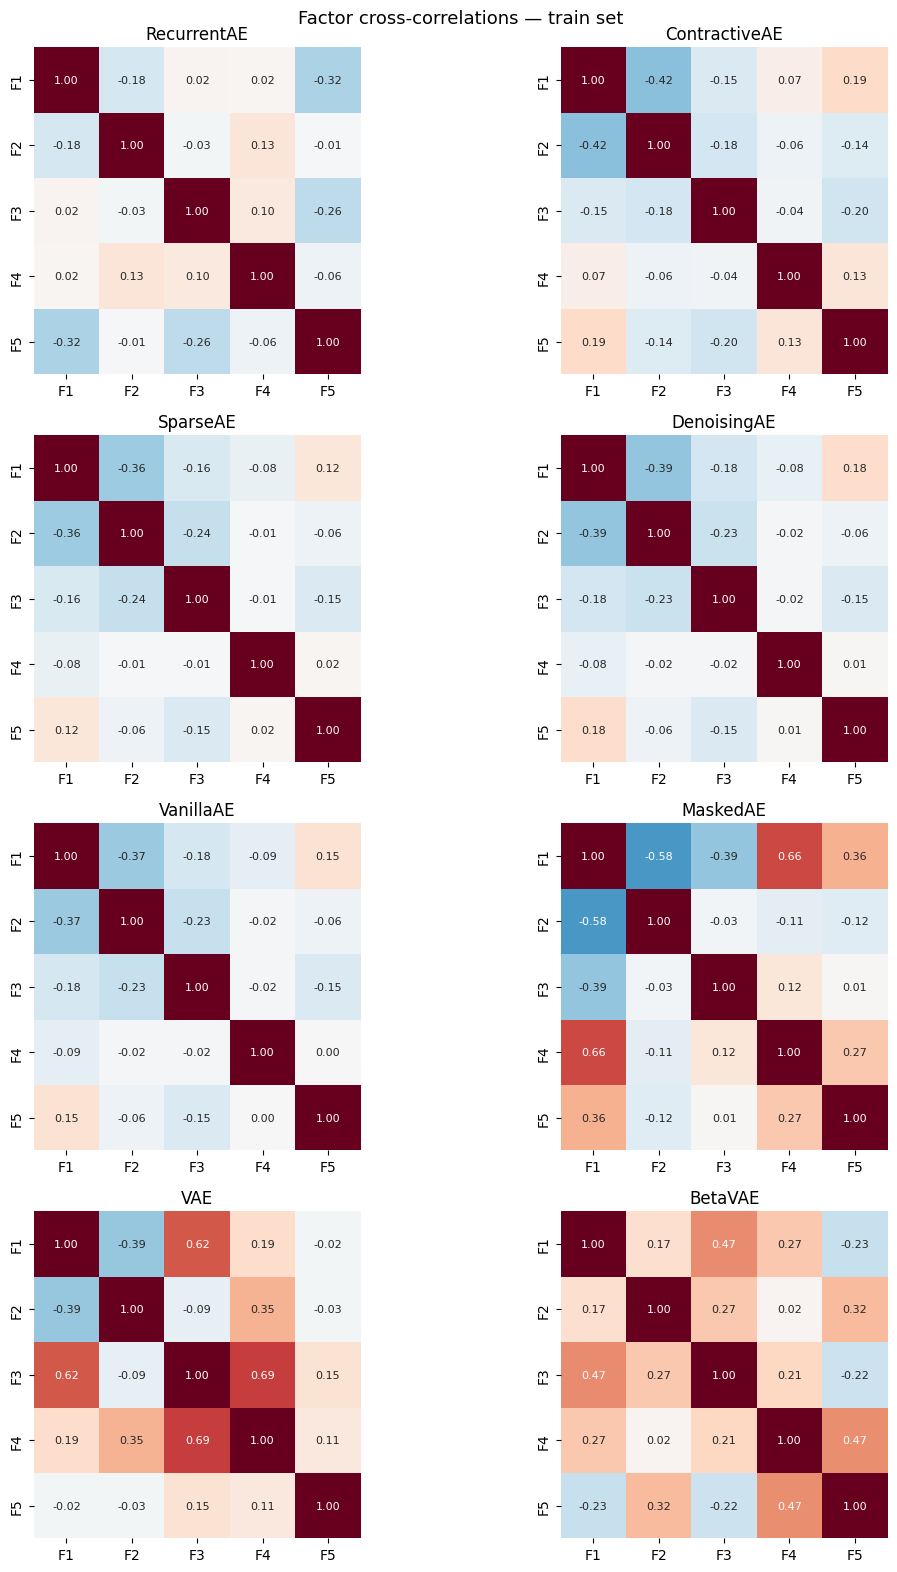

In [15]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()
for ax, name in zip(axes, arch_order):
    factors = pd.read_csv(FACTORS / f"{name}_train_factors.csv", index_col=0, parse_dates=True)
    sns.heatmap(
        factors.corr(), ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        annot=True, fmt=".2f", annot_kws={"size": 8}, square=True, cbar=False,
    )
    ax.set_title(name)
for ax in axes[len(arch_order):]:
    ax.set_visible(False)
fig.suptitle("Factor cross-correlations — train set", fontsize=13)
fig.tight_layout()
plt.show()

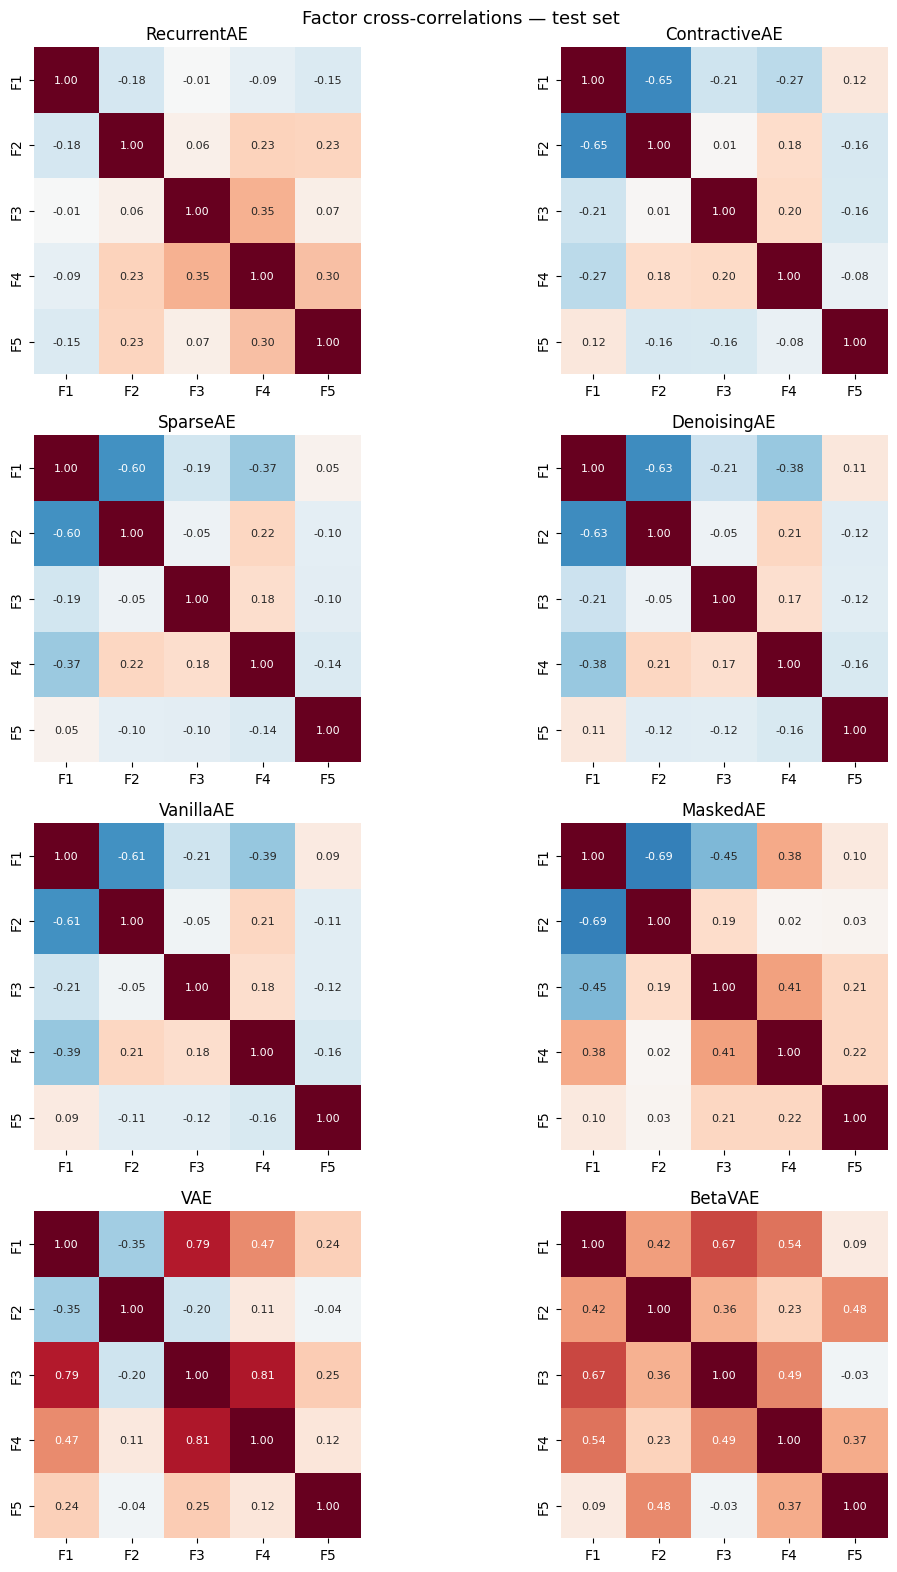

In [16]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()
for ax, name in zip(axes, arch_order):
    factors = pd.read_csv(FACTORS / f"{name}_test_factors.csv", index_col=0, parse_dates=True)
    sns.heatmap(
        factors.corr(), ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        annot=True, fmt=".2f", annot_kws={"size": 8}, square=True, cbar=False,
    )
    ax.set_title(name)
for ax in axes[len(arch_order):]:
    ax.set_visible(False)
fig.suptitle("Factor cross-correlations — test set", fontsize=13)
fig.tight_layout()
plt.show()

## 8. Latent Factor Interpretation

For each architecture and split, we compute the **correlation between each latent factor and each commodity return**. This is the autoencoder equivalent of PCA loadings — it shows which commodities each factor is tracking.

A factor with high positive correlation to Energy commodities can be interpreted as an "Energy factor"; one correlated with Metals as a "Metals factor", etc.

In [17]:
# Load raw returns and align to each split's date index
returns_raw = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)

SECTOR_MAP = {
    "Brent":"Energy","WTI":"Energy","NaturalGas":"Energy","Gasoline":"Energy",
    "Diesel":"Energy","HeatingOil":"Energy","ThermalCoal":"Energy","Methanol":"Energy",
    "Gold":"Metals","Silver":"Metals","Copper":"Metals","Aluminium":"Metals",
    "Nickel":"Metals","Zinc":"Metals","Platinum":"Metals","HRCSteel":"Metals",
    "SGXIronOre":"Metals","Lithium":"Metals",
    "Coffee":"Agriculture","Corn":"Agriculture","Cotton":"Agriculture",
    "LeanHogs":"Agriculture","LiveCattle":"Agriculture","Sugar":"Agriculture",
    "Soybeans":"Agriculture","SoybeanOil":"Agriculture","HRWWheat":"Agriculture",
}
SECTOR_ORDER = ["Energy", "Metals", "Agriculture"]
COMMODITIES_ORDERED = sorted(SECTOR_MAP, key=lambda c: (SECTOR_ORDER.index(SECTOR_MAP[c]), list(SECTOR_MAP).index(c)))

def factor_commodity_corr(arch, split):
    factors = pd.read_csv(FACTORS / f"{arch}_{split}_factors.csv", index_col=0, parse_dates=True)
    rets    = returns_raw.reindex(factors.index)[COMMODITIES_ORDERED]
    # correlation: rows = factors (F1..F5), cols = commodities
    return pd.DataFrame(
        {col: factors.corrwith(rets[col]) for col in rets.columns},
        index=factors.columns,
    )

### 8a. Factor–commodity correlation heatmaps (train then test)

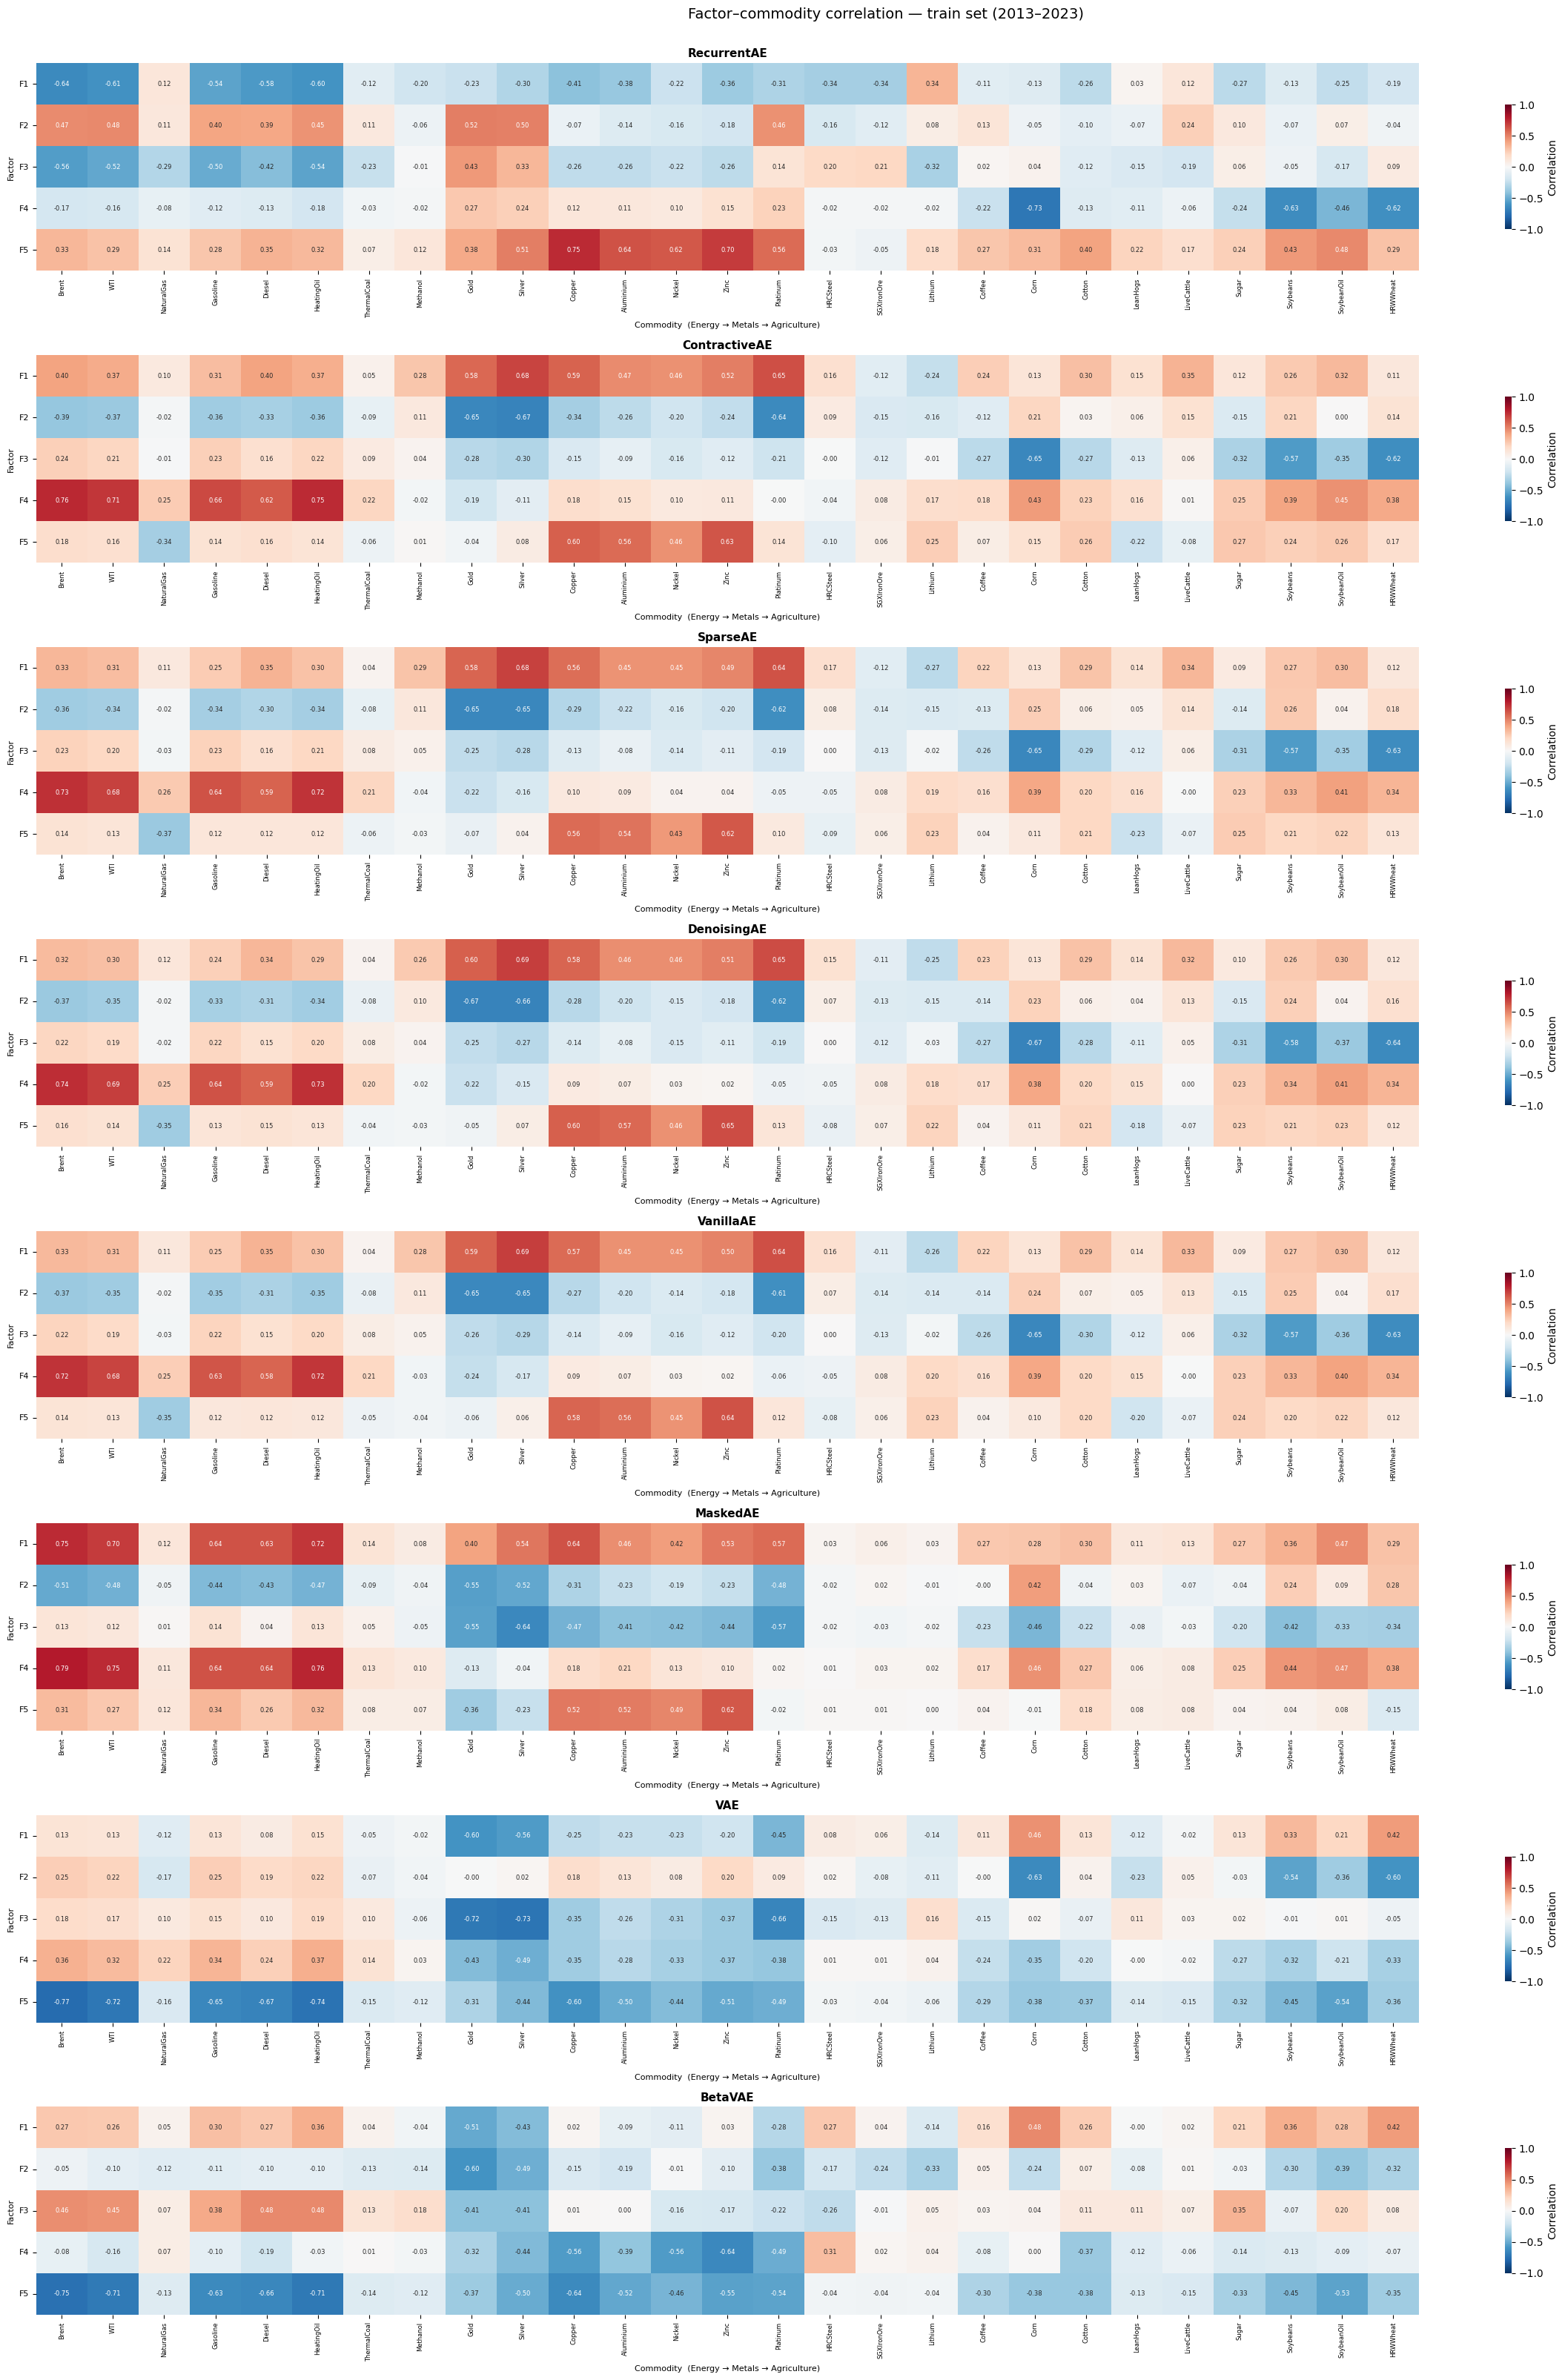

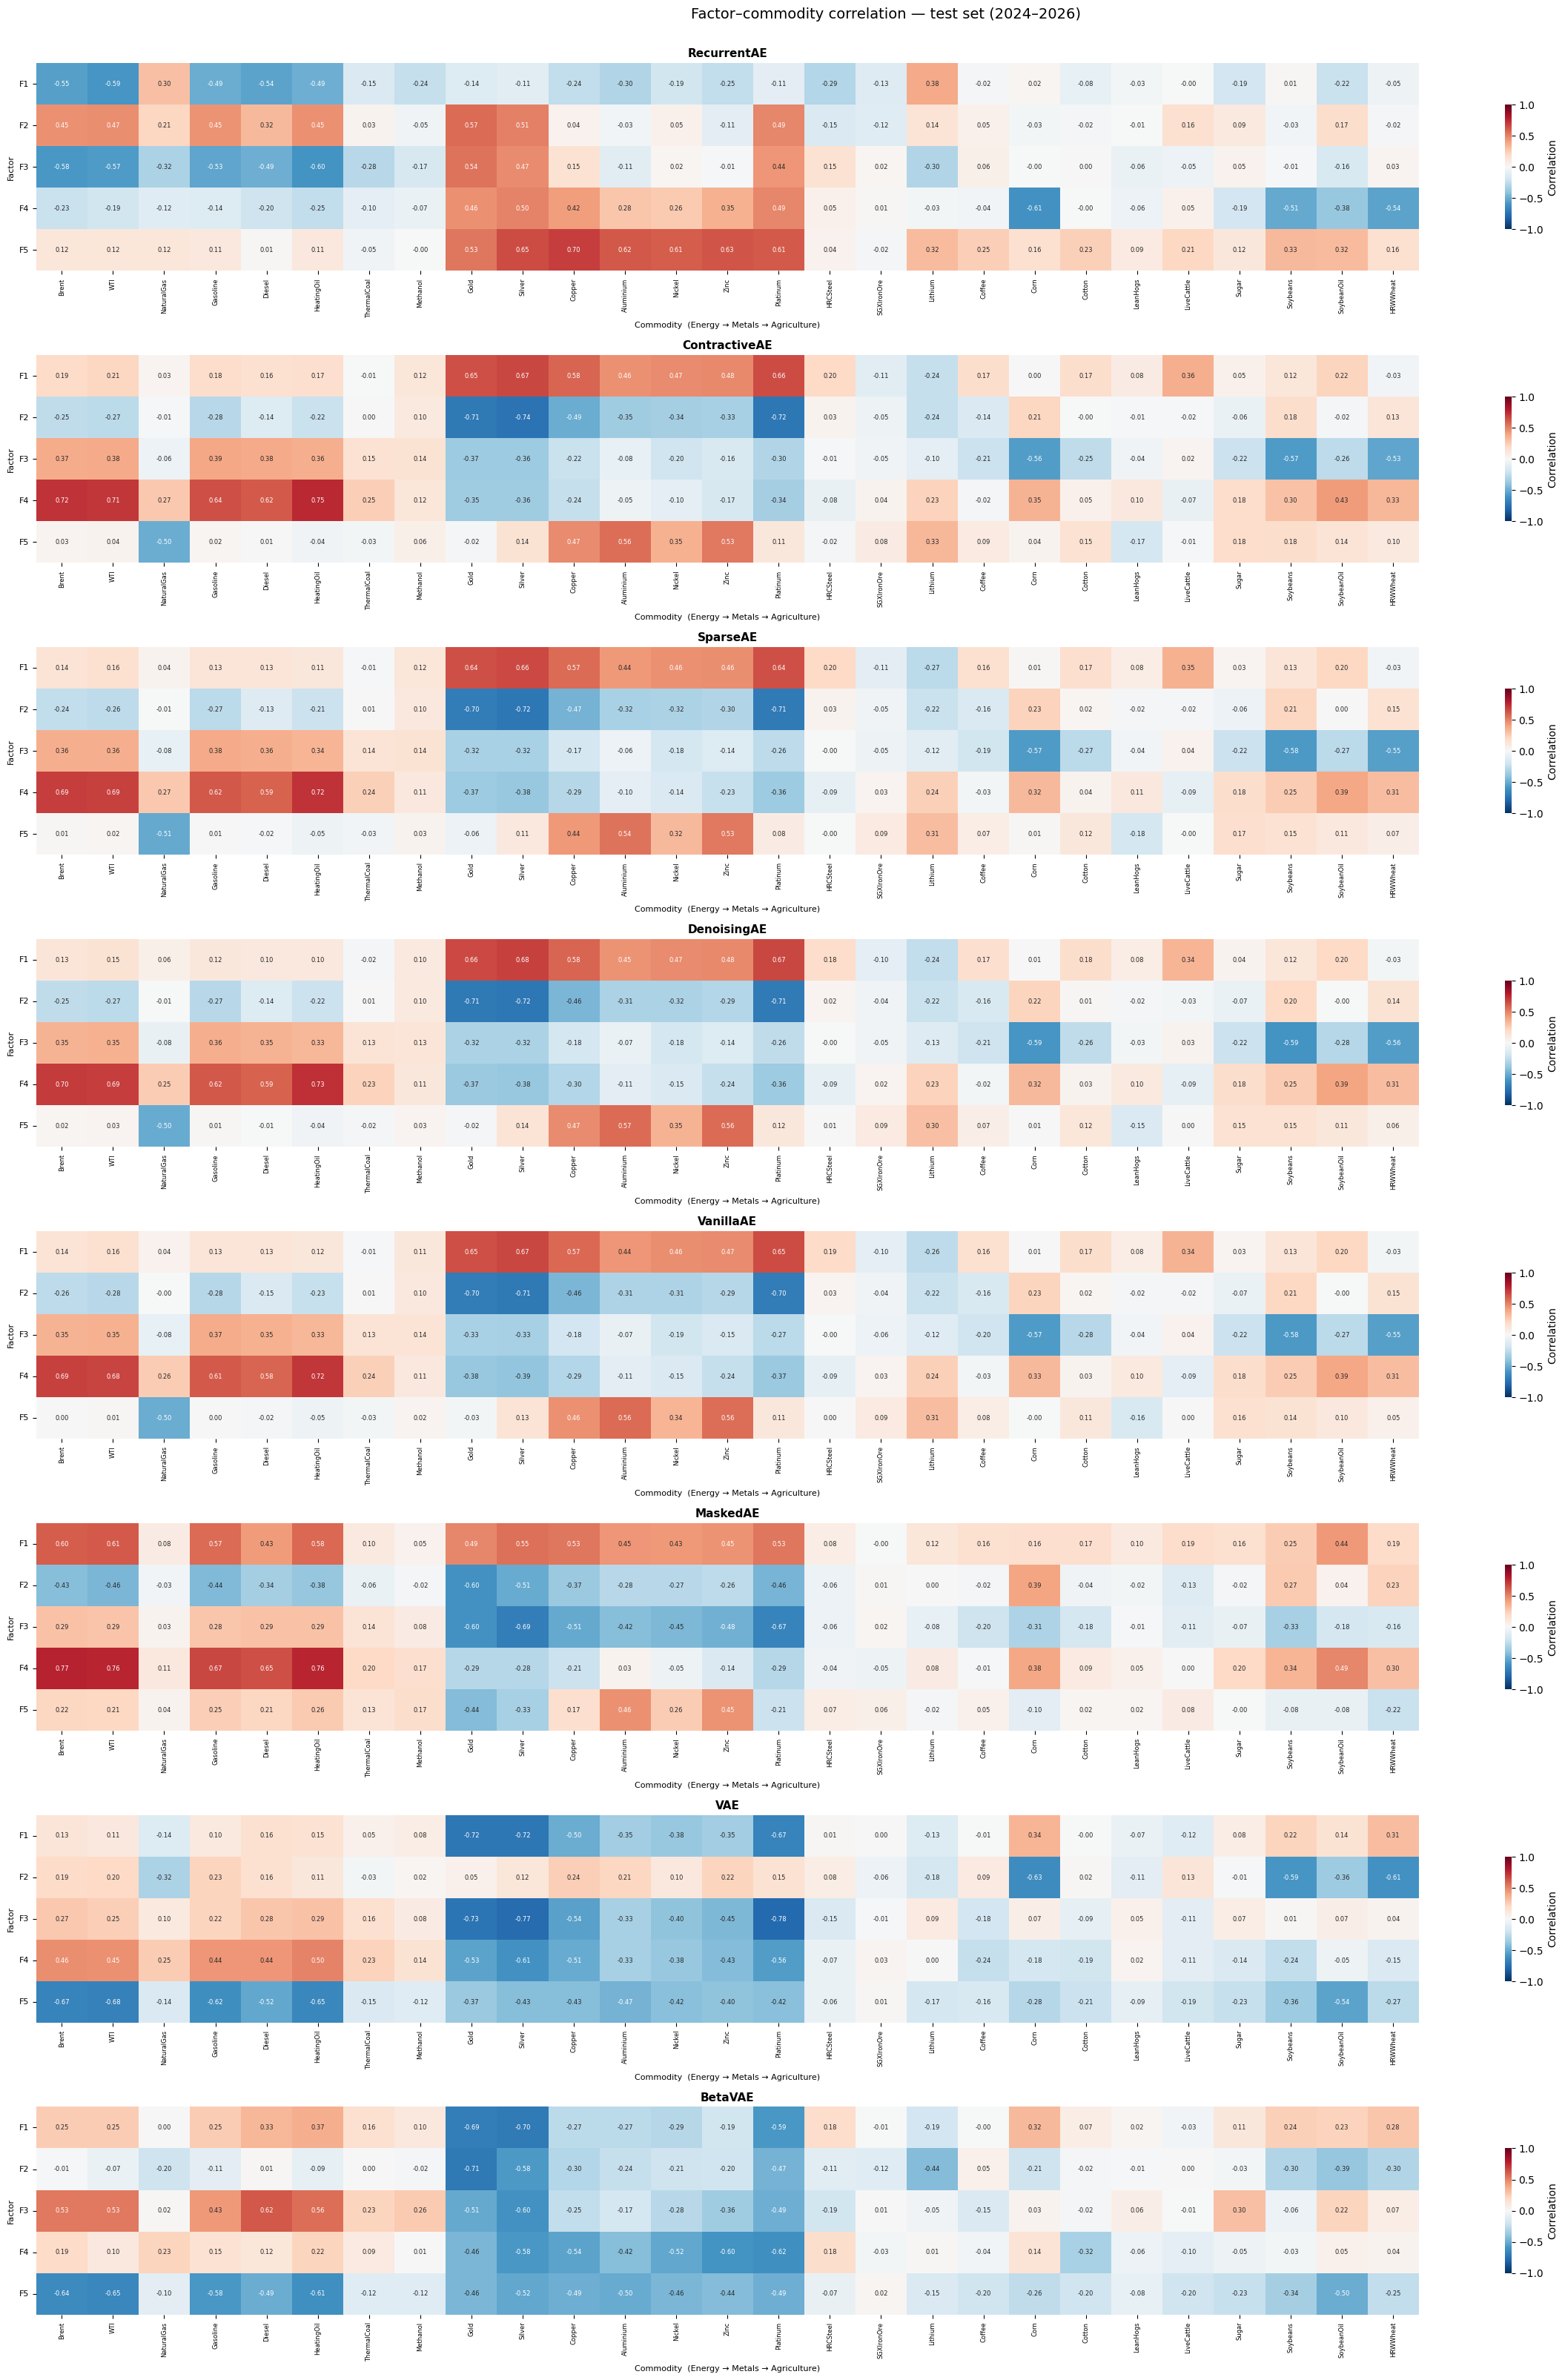

In [18]:
for split in ("train", "test"):
    n = len(arch_order)
    fig, axes = plt.subplots(n, 1, figsize=(24, 4 * n))
    if n == 1:
        axes = [axes]
    for ax, arch in zip(axes, arch_order):
        corr = factor_commodity_corr(arch, split)
        sns.heatmap(
            corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 6},
            xticklabels=corr.columns, yticklabels=corr.index, cbar=True,
            cbar_kws={"label": "Correlation", "shrink": 0.6},
        )
        ax.set_title(arch, fontsize=11, fontweight="bold")
        ax.set_xlabel("Commodity  (Energy → Metals → Agriculture)", fontsize=8)
        ax.set_ylabel("Factor", fontsize=8)
        ax.tick_params(axis="x", rotation=90, labelsize=6)
        ax.tick_params(axis="y", rotation=0, labelsize=8)
    year = "2013–2023" if split == "train" else "2024–2026"
    fig.suptitle(f"Factor–commodity correlation — {split} set ({year})", fontsize=14, y=1.002)
    fig.tight_layout()
    plt.show()

### 8b. Top commodities per factor (train, by absolute correlation)

In [19]:
TOP_N = 5

for arch in arch_order:
    corr = factor_commodity_corr(arch, "train")
    rows = []
    for factor in corr.index:
        top = corr.loc[factor].abs().nlargest(TOP_N)
        for rank, (com, abs_r) in enumerate(top.items(), 1):
            rows.append({
                "factor": factor,
                "rank": rank,
                "commodity": com,
                "sector": SECTOR_MAP[com],
                "correlation": round(corr.loc[factor, com], 3),
            })
    tbl = pd.DataFrame(rows).set_index(["factor", "rank"])
    print(f"\n{'─' * 60}")
    print(f"  {arch} — top {TOP_N} commodities per factor (train, |corr|)")
    print(f"{'─' * 60}")
    display(tbl)


────────────────────────────────────────────────────────────
  RecurrentAE — top 5 commodities per factor (train, |corr|)
────────────────────────────────────────────────────────────


commodity       sector  correlation
factor rank                                      
F1     1          Brent       Energy       -0.640
       2            WTI       Energy       -0.606
       3     HeatingOil       Energy       -0.597
       4         Diesel       Energy       -0.577
       5       Gasoline       Energy       -0.538
F2     1           Gold       Metals        0.516
       2         Silver       Metals        0.501
       3            WTI       Energy        0.481
       4          Brent       Energy        0.471
       5       Platinum       Metals        0.457
F3     1          Brent       Energy       -0.555
       2     HeatingOil       Energy       -0.537
       3            WTI       Energy       -0.521
       4       Gasoline       Energy       -0.502
       5           Gold       Metals        0.430
F4     1           Corn  Agriculture       -0.726
       2       Soybeans  Agriculture       -0.630
       3       HRWWheat  Agriculture       -0.617
       4     SoybeanOil  Agriculture       -0.456
       5           Gold       Metals        0.270
F5     1         Copper       Metals        0.747
       2           Zinc       Metals        0.700
       3      Aluminium       Metals        0.635
       4         Nickel       Metals        0.624
       5       Platinum       Metals        0.564


────────────────────────────────────────────────────────────
  ContractiveAE — top 5 commodities per factor (train, |corr|)
────────────────────────────────────────────────────────────


commodity       sector  correlation
factor rank                                      
F1     1         Silver       Metals        0.678
       2       Platinum       Metals        0.647
       3         Copper       Metals        0.587
       4           Gold       Metals        0.576
       5           Zinc       Metals        0.516
F2     1         Silver       Metals       -0.668
       2           Gold       Metals       -0.654
       3       Platinum       Metals       -0.638
       4          Brent       Energy       -0.388
       5            WTI       Energy       -0.370
F3     1           Corn  Agriculture       -0.654
       2       HRWWheat  Agriculture       -0.621
       3       Soybeans  Agriculture       -0.569
       4     SoybeanOil  Agriculture       -0.354
       5          Sugar  Agriculture       -0.320
F4     1          Brent       Energy        0.756
       2     HeatingOil       Energy        0.748
       3            WTI       Energy        0.711
       4       Gasoline       Energy        0.656
       5         Diesel       Energy        0.616
F5     1           Zinc       Metals        0.625
       2         Copper       Metals        0.598
       3      Aluminium       Metals        0.564
       4         Nickel       Metals        0.456
       5     NaturalGas       Energy       -0.336


────────────────────────────────────────────────────────────
  SparseAE — top 5 commodities per factor (train, |corr|)
────────────────────────────────────────────────────────────


...

commodity       sector  correlation
factor rank                                      
F1     1          Brent       Energy        0.750
       2     HeatingOil       Energy        0.715
       3            WTI       Energy        0.700
       4         Copper       Metals        0.639
       5       Gasoline       Energy        0.636
F2     1           Gold       Metals       -0.548
       2         Silver       Metals       -0.520
       3          Brent       Energy       -0.508
       4            WTI       Energy       -0.482
       5       Platinum       Metals       -0.475
F3     1         Silver       Metals       -0.641
       2       Platinum       Metals       -0.566
       3           Gold       Metals       -0.546
       4         Copper       Metals       -0.470
       5           Corn  Agriculture       -0.456
F4     1          Brent       Energy        0.795
       2     HeatingOil       Energy        0.764
       3            WTI       Energy        0.747
       4       Gasoline       Energy        0.640
       5         Diesel       Energy        0.640
F5     1           Zinc       Metals        0.619
       2         Copper       Metals        0.525
       3      Aluminium       Metals        0.517
       4         Nickel       Metals        0.489
       5           Gold       Metals       -0.358


────────────────────────────────────────────────────────────
  VAE — top 5 commodities per factor (train, |corr|)
────────────────────────────────────────────────────────────


commodity       sector  correlation
factor rank                                      
F1     1           Gold       Metals       -0.596
       2         Silver       Metals       -0.563
       3           Corn  Agriculture        0.459
       4       Platinum       Metals       -0.454
       5       HRWWheat  Agriculture        0.424
F2     1           Corn  Agriculture       -0.635
       2       HRWWheat  Agriculture       -0.595
       3       Soybeans  Agriculture       -0.538
       4     SoybeanOil  Agriculture       -0.355
       5          Brent       Energy        0.248
F3     1         Silver       Metals       -0.731
       2           Gold       Metals       -0.718
       3       Platinum       Metals       -0.664
       4           Zinc       Metals       -0.366
       5         Copper       Metals       -0.354
F4     1         Silver       Metals       -0.487
       2           Gold       Metals       -0.434
       3       Platinum       Metals       -0.385
       4     HeatingOil       Energy        0.367
       5           Zinc       Metals       -0.366
F5     1          Brent       Energy       -0.767
       2     HeatingOil       Energy       -0.735
       3            WTI       Energy       -0.723
       4         Diesel       Energy       -0.669
       5       Gasoline       Energy       -0.653


────────────────────────────────────────────────────────────
  BetaVAE — top 5 commodities per factor (train, |corr|)
────────────────────────────────────────────────────────────


commodity       sector  correlation
factor rank                                      
F1     1           Gold       Metals       -0.513
       2           Corn  Agriculture        0.482
       3         Silver       Metals       -0.430
       4       HRWWheat  Agriculture        0.424
       5       Soybeans  Agriculture        0.364
F2     1           Gold       Metals       -0.596
       2         Silver       Metals       -0.486
       3     SoybeanOil  Agriculture       -0.390
       4       Platinum       Metals       -0.379
       5        Lithium       Metals       -0.328
F3     1     HeatingOil       Energy        0.480
       2         Diesel       Energy        0.477
       3          Brent       Energy        0.465
       4            WTI       Energy        0.450
       5           Gold       Metals       -0.412
F4     1           Zinc       Metals       -0.641
       2         Copper       Metals       -0.563
       3         Nickel       Metals       -0.563
       4       Platinum       Metals       -0.494
       5         Silver       Metals       -0.444
F5     1          Brent       Energy       -0.749
       2     HeatingOil       Energy       -0.712
       3            WTI       Energy       -0.707
       4         Diesel       Energy       -0.655
       5         Copper       Metals       -0.638